# Dataset Imputed Analysis

This notebook analyzes missing values, correlations, distributions, and outliers in the imputed dataset.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

path = Path("../data/mock/new/dataset_imputed.csv")
if not path.exists():
    raise FileNotFoundError(f"Missing input file: {path.resolve()}")

df = pd.read_csv(path)
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
df.head()

Rows: 615,040 | Columns: 7


,temperature,humidity,light,co2,noise,id,timestamp
0,23.7000,26.272,585.200000,749.200000,42.213017,NaN,02/02/15 14:19
1,23.7180,26.290,578.400000,760.400000,42.053776,NaN,02/02/15 14:19
2,23.7300,26.230,572.666667,769.666667,41.921038,NaN,02/02/15 14:21
3,23.7225,26.125,493.750000,774.750000,41.948611,NaN,02/02/15 14:22
4,23.7540,26.200,488.600000,779.000000,41.892594,NaN,02/02/15 14:23


## Missing Values

,column,missing_count,missing_pct
0,id,2665,0.433305
1,humidity,0,0.000000
2,temperature,0,0.000000
3,light,0,0.000000
4,co2,0,0.000000
5,noise,0,0.000000
6,timestamp,0,0.000000


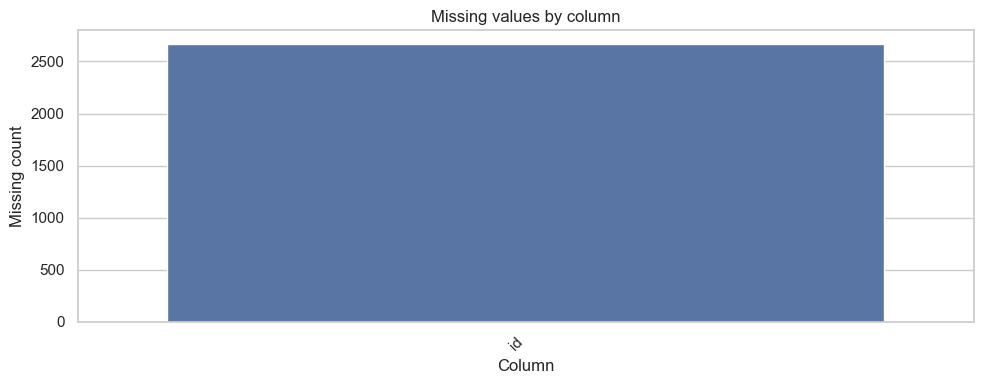

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .sort_values(by="missing_count", ascending=False)
    .reset_index().rename(columns={"index": "column"})
)

display(missing_summary)

missing_nonzero = missing_summary[missing_summary["missing_count"] > 0]
if missing_nonzero.empty:
    print("No missing values found.")
else:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=missing_nonzero, x="column", y="missing_count", color="#4c72b0")
    plt.xticks(rotation=45, ha="right")
    plt.title("Missing values by column")
    plt.xlabel("Column")
    plt.ylabel("Missing count")
    plt.tight_layout()
    plt.show()

## Correlation (Numeric Features)

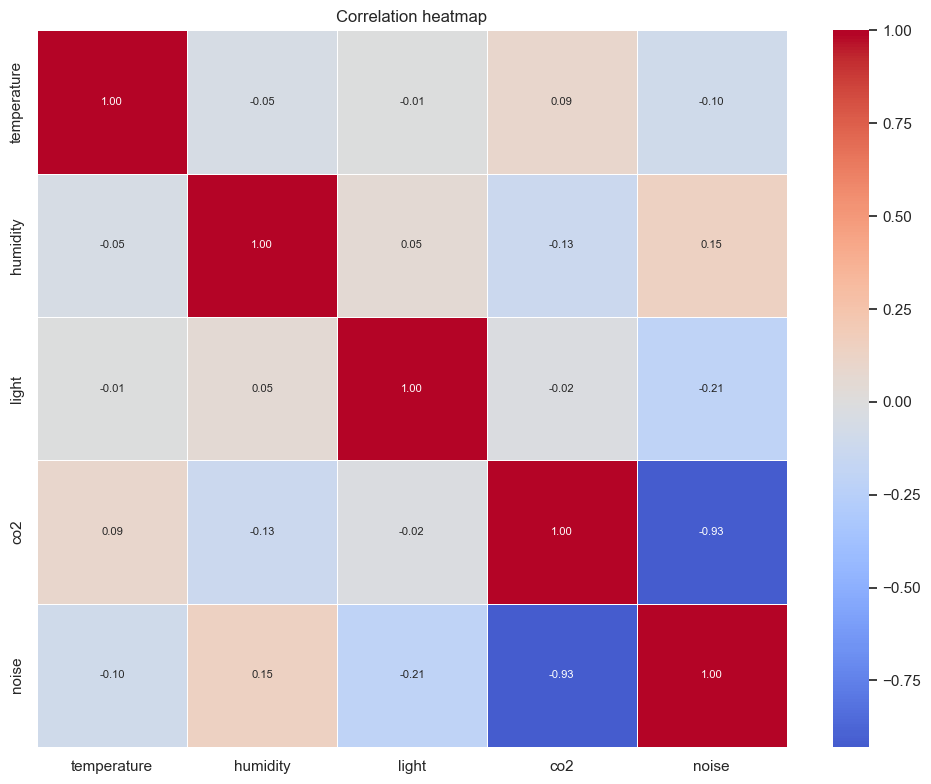

In [8]:
numeric_df = df.select_dtypes(include=np.number)
if numeric_df.empty:
    print("No numeric columns found for correlation.")
else:
    corr = numeric_df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
    )
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()

## Distribution of Numeric Features

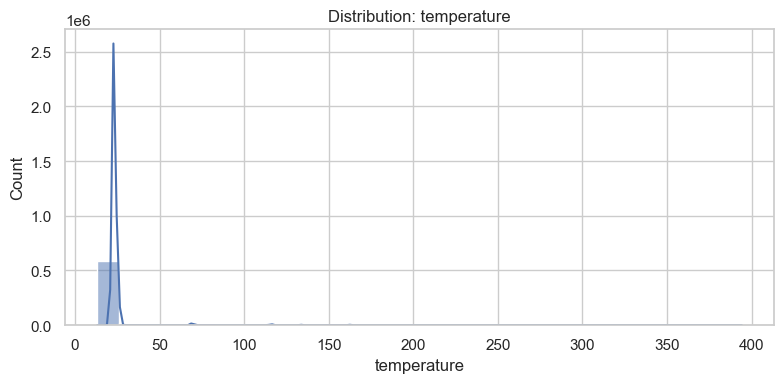

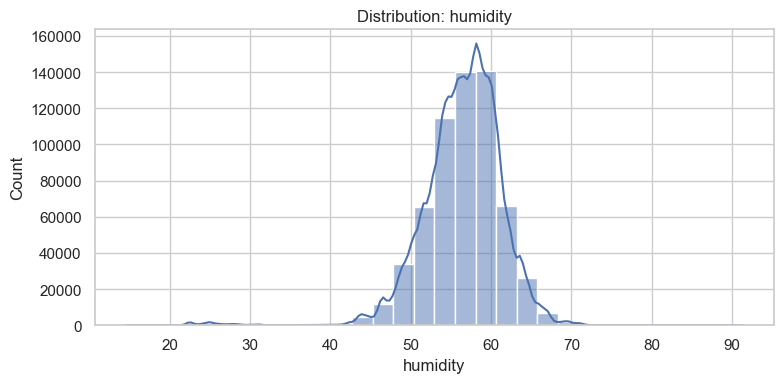

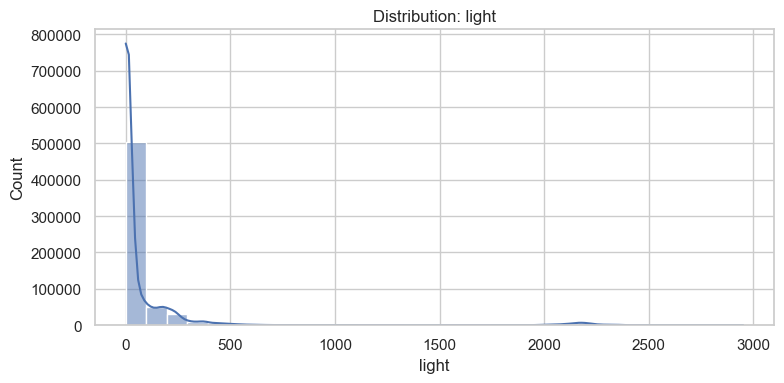

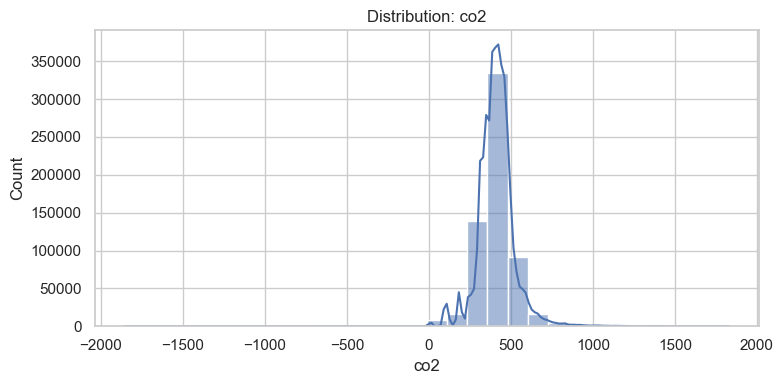

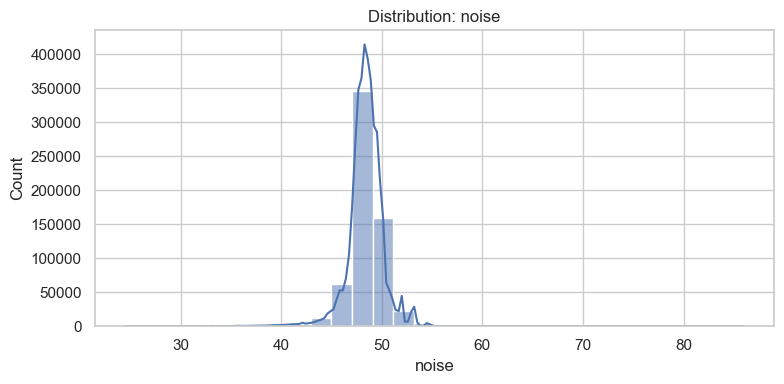

In [9]:
if numeric_df.empty:
    print("No numeric columns found for distribution plots.")
else:
    for col in numeric_df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(numeric_df[col].dropna(), bins=30, kde=True, color="#4c72b0")
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

## Outliers (IQR Method)

,column,outlier_count,outlier_pct
2,light,103938,16.899389
4,noise,36867,5.994244
0,temperature,36776,5.979448
3,co2,35207,5.724343
1,humidity,10314,1.676964


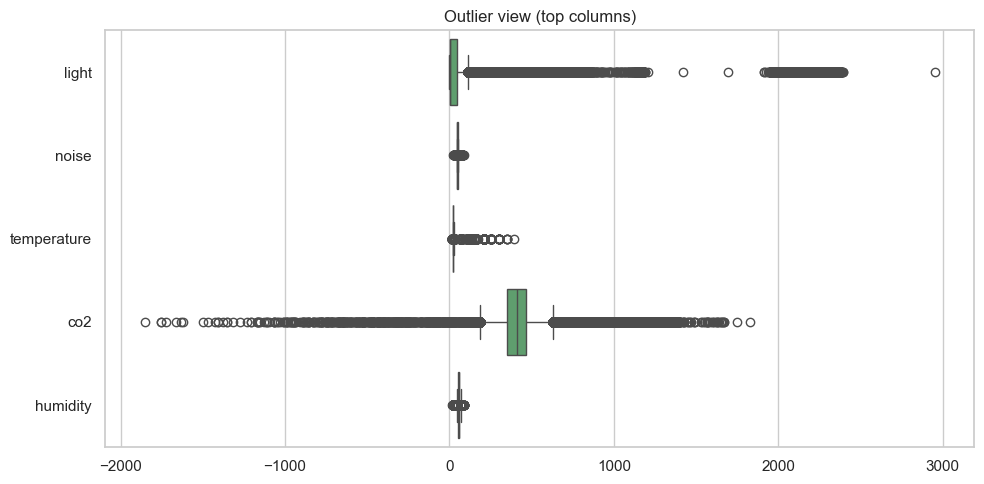

In [10]:
if numeric_df.empty:
    print("No numeric columns found for outlier analysis.")
else:
    outlier_stats = []
    for col in numeric_df.columns:
        series = numeric_df[col].dropna()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            lower, upper = q1, q3
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
        outliers = ((series < lower) | (series > upper)).sum()
        outlier_pct = (outliers / len(series)) * 100 if len(series) else 0
        outlier_stats.append({
            "column": col,
            "outlier_count": int(outliers),
            "outlier_pct": float(outlier_pct),
        })
    outlier_df = pd.DataFrame(outlier_stats).sort_values(by="outlier_pct", ascending=False)
    display(outlier_df)

    top_cols = outlier_df[outlier_df["outlier_count"] > 0].head(6)["column"].tolist()
    if not top_cols:
        print("No outliers detected by IQR rule.")
    else:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=numeric_df[top_cols], orient="h", color="#55a868")
        plt.title("Outlier view (top columns)")
        plt.tight_layout()
        plt.show()